# Reprodução do Experimento SOME/IP IDS — CTGAN + XGBoost

Notebook preparado para Google Colab.

Estrutura esperada:

```text
/content/datasets/
  X_train.npy
  y_train.npy
  X_test.npy
  y_test.npy
```

Objetivo:

1. Validar distribuição do dataset.
2. Criar teste balanceado por downsampling.
3. Treinar baseline XGBoost sem CTGAN.
4. Criar validação de threshold e normalizar features por Min-Max.
5. Treinar CTGAN apenas com ataques do treino.
5. Gerar ataques sintéticos até balancear o treino.
6. Treinar XGBoost com hiperparâmetros do artigo.
7. Avaliar em cenário realista desbalanceado e cenário controlado balanceado.

Referência de parâmetros do artigo:

- XGBoost: 1000 árvores, learning rate 0.05, max depth 6, subsample 0.8, colsample 0.8, min child weight 1, lambda 1, gamma 0.
- CTGAN: embedding_dim 128, generator/critic 256/256, batch_size 500, pac 10, epochs 100.


## 0. Instalação das dependências

No Colab, rode esta célula primeiro. Se usar GPU, vá em **Runtime > Change runtime type > GPU**.


In [1]:
!pip -q install xgboost scikit-learn pandas numpy matplotlib sdv ctgan joblib pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.7/204.7 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 1.8 MB/s eta 0:00:00


In [14]:
!pip install ctgan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 78.0 MB/s eta 0:00:00


In [15]:
!pip show ctgan

Name: ctgan
Version: 0.12.1
Summary: Create tabular synthetic data using a conditional GAN
Home-page: 
Author: 
Author-email: "DataCebo, Inc." <info@sdv.dev>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy, pandas, rdt, torch, tqdm
Required-by: 


## 1. Imports e configuração global

In [3]:
import os
import gc
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import resample

import xgboost as xgb
import joblib

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
DATA_DIR = Path('/content/datasets')
OUT_DIR = Path('/content/outputs_someip_xgboost')
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('DATA_DIR:', DATA_DIR)
print('OUT_DIR:', OUT_DIR)


DATA_DIR: /content/datasets
OUT_DIR: /content/outputs_someip_xgboost


## 2. Parâmetros de execução

Para reprodução completa, deixe `RUN_FULL_CTGAN = True` e `CTGAN_EPOCHS = 100`.

Para validar rapidamente o pipeline, use `QUICK_MODE = True`.


In [4]:
# Modo rápido para testar se tudo funciona antes do treino completo.
QUICK_MODE = False

# CTGAN completo pode demorar bastante. Em Colab gratuito pode ser pesado.
RUN_FULL_CTGAN = True

# Reproduz o paper com avaliação "training-side":
# - separa uma validação estratificada dentro do treino para escolher threshold;
# - o test set continua intocado.
USE_VALIDATION_SPLIT = True
VALIDATION_SIZE = 0.10

# Normalização Min-Max descrita na Seção 5.3 do artigo.
# Importante principalmente para CTGAN, pois XGBoost é pouco sensível à escala,
# mas o gerador tabular é bastante sensível.
APPLY_MINMAX_NORMALIZATION = True
CLIP_TEST_TO_TRAIN_RANGE = True

# Estratégia de geração sintética:
# 'paper_table'  -> gera aproximadamente N_normal sintéticos.
#                   Isso reproduz a Tabela 3: normal=6.285.515 e attack real+synth=7.116.673.
# 'balanced_final' -> gera até ataque_final == normal.
SYNTHETIC_STRATEGY = 'paper_table'

# Clipping dos sintéticos não é descrito no paper. Deixe False para reprodução fiel.
CLIP_SYNTHETIC_TO_ATTACK_RANGE = False

# Thresholds adicionais para análise operacional de IDS.
TARGET_RECALL = 0.97
FBETA_BETA = 2.0

# Parâmetros CTGAN do artigo
CTGAN_EPOCHS = 100
CTGAN_BATCH_SIZE = 500
CTGAN_EMBEDDING_DIM = 128
CTGAN_GENERATOR_DIM = (256, 256)
CTGAN_DISCRIMINATOR_DIM = (256, 256)
CTGAN_PAC = 10

# Se QUICK_MODE=True, limita amostras para teste do notebook
QUICK_TRAIN_SAMPLES = 300_000
QUICK_TEST_SAMPLES = 300_000
QUICK_ATTACK_CTGAN_SAMPLES = 100_000
QUICK_CTGAN_EPOCHS = 5

# Para economizar RAM, o dataset aumentado pode ser salvo.
SAVE_SYNTHETIC_ATTACKS = True
SYNTHETIC_PATH = OUT_DIR / 'synthetic_attacks.npy'

# XGBoost do artigo
XGB_PARAMS = dict(
    objective='binary:logistic',
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    reg_lambda=1.0,
    gamma=0.0,
    eval_metric='aucpr',
    tree_method='hist',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print(json.dumps({
    'QUICK_MODE': QUICK_MODE,
    'RUN_FULL_CTGAN': RUN_FULL_CTGAN,
    'USE_VALIDATION_SPLIT': USE_VALIDATION_SPLIT,
    'VALIDATION_SIZE': VALIDATION_SIZE,
    'APPLY_MINMAX_NORMALIZATION': APPLY_MINMAX_NORMALIZATION,
    'SYNTHETIC_STRATEGY': SYNTHETIC_STRATEGY,
    'CLIP_SYNTHETIC_TO_ATTACK_RANGE': CLIP_SYNTHETIC_TO_ATTACK_RANGE,
    'TARGET_RECALL': TARGET_RECALL,
    'CTGAN_EPOCHS': CTGAN_EPOCHS,
    'XGB_PARAMS': XGB_PARAMS,
}, indent=2, default=str))


{
  "QUICK_MODE": false,
  "RUN_FULL_CTGAN": true,
  "CTGAN_EPOCHS": 100,
  "XGB_PARAMS": {
    "objective": "binary:logistic",
    "n_estimators": 1000,
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 1,
    "reg_lambda": 1.0,
    "gamma": 0.0,
    "eval_metric": "aucpr",
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": -1
  }
}


## 3. Carregamento dos `.npy`

Usa `mmap_mode='r'` para reduzir RAM durante inspeção. Algumas etapas precisam materializar arrays em memória.

In [6]:
required_files = ['X_train.npy', 'y_train.npy', 'X_test.npy', 'y_test.npy']
for f in required_files:
    path = DATA_DIR / f
    if not path.exists():
        raise FileNotFoundError(f'Arquivo não encontrado: {path}')

X_train = np.load(DATA_DIR / 'X_train.npy', mmap_mode='r')
y_train = np.load(DATA_DIR / 'y_train.npy', mmap_mode='r')
X_test = np.load(DATA_DIR / 'X_test.npy' ,mmap_mode='r' )
y_test = np.load(DATA_DIR / 'y_test.npy', mmap_mode='r')

print('X_train:', X_train.shape, X_train.dtype)
print('y_train:', y_train.shape, y_train.dtype)
print('X_test :', X_test.shape, X_test.dtype)
print('y_test :', y_test.shape, y_test.dtype)

X_train: (7116674, 12) float32
y_train: (7116674,) int64
X_test : (7116673, 12) float32
y_test : (7116673,) int64


## 4. Validação da distribuição de classes

In [7]:
def class_counts(y):
    vals, counts = np.unique(np.asarray(y), return_counts=True)
    return dict(zip(vals.astype(int).tolist(), counts.astype(int).tolist()))

train_counts = class_counts(y_train)
test_counts = class_counts(y_test)

print('Train counts:', train_counts)
print('Test counts :', test_counts)

summary = pd.DataFrame([
    {'split': 'train_original', 'normal_0': train_counts.get(0, 0), 'attack_1': train_counts.get(1, 0), 'total': len(y_train)},
    {'split': 'test_imbalanced', 'normal_0': test_counts.get(0, 0), 'attack_1': test_counts.get(1, 0), 'total': len(y_test)},
])
summary['attack_pct'] = summary['attack_1'] / summary['total'] * 100
summary['normal_pct'] = summary['normal_0'] / summary['total'] * 100
summary


Train counts: {0: 6285515, 1: 831159}
Test counts : {0: 6285514, 1: 831159}


,split,normal_0,attack_1,total,attack_pct,normal_pct
0,train_original,6285515,831159,7116674,11.679037,88.320963
1,test_imbalanced,6285514,831159,7116673,11.679039,88.320961


## 5. Preparar subconjuntos caso `QUICK_MODE=True`

In [8]:
def stratified_indices(y, n_total, random_state=42):
    rng = np.random.default_rng(random_state)
    y_arr = np.asarray(y)
    classes, counts = np.unique(y_arr, return_counts=True)
    idx_all = []
    for c, count in zip(classes, counts):
        cls_idx = np.where(y_arr == c)[0]
        n_c = max(1, int(round(n_total * count / len(y_arr))))
        n_c = min(n_c, len(cls_idx))
        idx_all.append(rng.choice(cls_idx, size=n_c, replace=False))
    idx = np.concatenate(idx_all)
    rng.shuffle(idx)
    return idx

if QUICK_MODE:
    train_idx = stratified_indices(y_train, QUICK_TRAIN_SAMPLES, RANDOM_STATE)
    test_idx = stratified_indices(y_test, QUICK_TEST_SAMPLES, RANDOM_STATE)
    X_train_work = np.asarray(X_train[train_idx], dtype=np.float32)
    y_train_work = np.asarray(y_train[train_idx], dtype=np.int8)
    X_test_work = np.asarray(X_test[test_idx], dtype=np.float32)
    y_test_work = np.asarray(y_test[test_idx], dtype=np.int8)
else:
    # Cuidado: materializar tudo em RAM. Necessário para treino completo do XGBoost/sklearn.
    X_train_work = np.asarray(X_train, dtype=np.float32)
    y_train_work = np.asarray(y_train, dtype=np.int8)
    X_test_work = np.asarray(X_test, dtype=np.float32)
    y_test_work = np.asarray(y_test, dtype=np.int8)

print('Work train:', X_train_work.shape, class_counts(y_train_work))
print('Work test :', X_test_work.shape, class_counts(y_test_work))


Work train: (7116674, 12) {0: 6285515, 1: 831159}
Work test : (7116673, 12) {0: 6285514, 1: 831159}


## 5B. Split treino/validação e normalização Min-Max

O artigo informa que o threshold é escolhido em avaliação do lado de treino/validação e que as variáveis contínuas são normalizadas por Min-Max. Esta etapa implementa esses dois pontos antes de treinar o baseline e o modelo CTGAN + XGBoost.


In [ ]:
# 1) Split de validação estratificado dentro do treino, usado somente para threshold.
#    O conjunto de teste permanece intocado.
if USE_VALIDATION_SPLIT and 0 < VALIDATION_SIZE < 1:
    sss = StratifiedShuffleSplit(
        n_splits=1,
        test_size=VALIDATION_SIZE,
        random_state=RANDOM_STATE
    )
    model_idx, val_idx = next(sss.split(X_train_work, y_train_work))

    X_train_model_raw = X_train_work[model_idx]
    y_train_model = y_train_work[model_idx]

    X_val_threshold_raw = X_train_work[val_idx]
    y_val_threshold = y_train_work[val_idx]
else:
    # Modo compatível com o notebook anterior: threshold calculado no próprio treino.
    X_train_model_raw = X_train_work
    y_train_model = y_train_work
    X_val_threshold_raw = X_train_work
    y_val_threshold = y_train_work

print('Model train:', X_train_model_raw.shape, class_counts(y_train_model))
print('Threshold validation:', X_val_threshold_raw.shape, class_counts(y_val_threshold))

# 2) Normalização Min-Max.
#    Fita apenas no conjunto usado para treinamento do modelo para evitar vazamento do teste.
if APPLY_MINMAX_NORMALIZATION:
    scaler = MinMaxScaler(copy=True)
    X_train_model = scaler.fit_transform(X_train_model_raw).astype(np.float32)
    X_val_threshold = scaler.transform(X_val_threshold_raw).astype(np.float32)
    X_test_work = scaler.transform(X_test_work).astype(np.float32)

    if CLIP_TEST_TO_TRAIN_RANGE:
        X_val_threshold = np.clip(X_val_threshold, 0.0, 1.0).astype(np.float32)
        X_test_work = np.clip(X_test_work, 0.0, 1.0).astype(np.float32)

    joblib.dump(scaler, OUT_DIR / 'minmax_scaler.joblib')
else:
    scaler = None
    X_train_model = X_train_model_raw.astype(np.float32, copy=False)
    X_val_threshold = X_val_threshold_raw.astype(np.float32, copy=False)

# Libera referências cruas grandes quando a normalização estiver aplicada.
if APPLY_MINMAX_NORMALIZATION:
    del X_train_model_raw, X_val_threshold_raw
    gc.collect()

print('X_train_model:', X_train_model.shape, X_train_model.dtype)
print('X_val_threshold:', X_val_threshold.shape, X_val_threshold.dtype)
print('X_test_work:', X_test_work.shape, X_test_work.dtype)


## 6. Criar teste balanceado por downsampling

Cenário B do artigo/slide: mesma quantidade de normais e ataques no teste.

In [9]:
def make_balanced_test(X, y, random_state=42):
    rng = np.random.default_rng(random_state)
    y = np.asarray(y)
    normal_idx = np.where(y == 0)[0]
    attack_idx = np.where(y == 1)[0]
    n = min(len(normal_idx), len(attack_idx))
    normal_down = rng.choice(normal_idx, size=n, replace=False)
    attack_down = rng.choice(attack_idx, size=n, replace=False)
    idx = np.concatenate([normal_down, attack_down])
    rng.shuffle(idx)
    return X[idx], y[idx], idx

X_test_bal, y_test_bal, test_bal_idx = make_balanced_test(X_test_work, y_test_work, RANDOM_STATE)
print('Balanced test:', X_test_bal.shape, class_counts(y_test_bal))


Balanced test: (1662318, 12) {0: 831159, 1: 831159}


## 7. Funções de avaliação e threshold ótimo

O artigo menciona seleção de threshold maximizando F1, em vez de usar 0.5 fixo.

In [10]:
def find_best_threshold_by_f1(y_true, y_score):
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
    best_idx = int(np.nanargmax(f1))
    return float(thresholds[best_idx]), float(f1[best_idx]), float(precision[best_idx]), float(recall[best_idx])


def find_best_threshold_by_fbeta(y_true, y_score, beta=2.0):
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    beta2 = beta ** 2
    fbeta = (1 + beta2) * precision[:-1] * recall[:-1] / (beta2 * precision[:-1] + recall[:-1] + 1e-12)
    best_idx = int(np.nanargmax(fbeta))
    return float(thresholds[best_idx]), float(fbeta[best_idx]), float(precision[best_idx]), float(recall[best_idx])


def find_threshold_for_target_recall(y_true, y_score, target_recall=0.97):
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    candidates = []
    for p, r, t in zip(precision[:-1], recall[:-1], thresholds):
        if r >= target_recall:
            candidates.append((float(p), float(r), float(t)))

    if not candidates:
        return None

    # Entre todos que atingem o recall alvo, escolhe o de maior precisão.
    best_precision, best_recall, best_threshold = max(candidates, key=lambda x: x[0])
    return best_threshold, best_precision, best_recall


def evaluate_scores(y_true, y_score, threshold=None, label='eval'):
    pr_auc = average_precision_score(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score)
    if threshold is None:
        threshold, _, _, _ = find_best_threshold_by_f1(y_true, y_score)

    y_pred = (y_score >= threshold).astype(np.int8)
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    out = {
        'label': label,
        'threshold': float(threshold),
        'pr_auc': float(pr_auc),
        'roc_auc': float(roc_auc),
        'f1': float(f1),
        'precision': float(precision),
        'recall': float(recall),
        'tn': int(cm[0,0]),
        'fp': int(cm[0,1]),
        'fn': int(cm[1,0]),
        'tp': int(cm[1,1]),
        'fp_per_million_normal': float(cm[0,1] / max(cm[0,0] + cm[0,1], 1) * 1_000_000),
        'fn_per_million_attack': float(cm[1,0] / max(cm[1,0] + cm[1,1], 1) * 1_000_000),
    }
    return out


def print_eval(result):
    print(json.dumps(result, indent=2))


## 8. Baseline: XGBoost sem CTGAN

Este experimento não é o resultado final do artigo, mas serve como controle para medir o ganho do CTGAN.

In [11]:
start = time.time()

xgb_baseline = xgb.XGBClassifier(**XGB_PARAMS)
xgb_baseline.fit(X_train_model, y_train_model)

# Threshold escolhido no conjunto de validação do lado de treino.
score_val_base = xgb_baseline.predict_proba(X_val_threshold)[:, 1]
threshold_base, f1_base_val, p_base_val, r_base_val = find_best_threshold_by_f1(y_val_threshold, score_val_base)
print('Baseline threshold from validation:', threshold_base, 'val F1:', f1_base_val, 'precision:', p_base_val, 'recall:', r_base_val)

# Threshold alternativo operacional para recall alvo.
target_base = find_threshold_for_target_recall(y_val_threshold, score_val_base, TARGET_RECALL)
if target_base is not None:
    threshold_base_recall, p_base_recall_val, r_base_recall_val = target_base
    print('Baseline threshold for target recall:', threshold_base_recall, 'val precision:', p_base_recall_val, 'val recall:', r_base_recall_val)
else:
    threshold_base_recall = None
    print(f'Não foi possível atingir recall >= {TARGET_RECALL} na validação do baseline.')

# Threshold F-beta, útil para IDS quando falso negativo é mais caro.
threshold_base_fbeta, fbeta_base_val, p_base_fbeta_val, r_base_fbeta_val = find_best_threshold_by_fbeta(
    y_val_threshold, score_val_base, beta=FBETA_BETA
)
print(f'Baseline threshold F{FBETA_BETA}:', threshold_base_fbeta, 'val F-beta:', fbeta_base_val, 'precision:', p_base_fbeta_val, 'recall:', r_base_fbeta_val)

gc.collect()

score_test_imb_base = xgb_baseline.predict_proba(X_test_work)[:, 1]
score_test_bal_base = xgb_baseline.predict_proba(X_test_bal)[:, 1]

baseline_results = [
    evaluate_scores(y_test_work, score_test_imb_base, threshold_base, 'baseline_test_imbalanced_f1_val_threshold'),
    evaluate_scores(y_test_bal, score_test_bal_base, threshold_base, 'baseline_test_balanced_f1_val_threshold'),
    evaluate_scores(y_test_work, score_test_imb_base, threshold_base_fbeta, f'baseline_test_imbalanced_f{FBETA_BETA}_val_threshold'),
    evaluate_scores(y_test_bal, score_test_bal_base, threshold_base_fbeta, f'baseline_test_balanced_f{FBETA_BETA}_val_threshold'),
]

if threshold_base_recall is not None:
    baseline_results.extend([
        evaluate_scores(y_test_work, score_test_imb_base, threshold_base_recall, f'baseline_test_imbalanced_recall_{TARGET_RECALL}_threshold'),
        evaluate_scores(y_test_bal, score_test_bal_base, threshold_base_recall, f'baseline_test_balanced_recall_{TARGET_RECALL}_threshold'),
    ])

for r in baseline_results:
    print_eval(r)

joblib.dump(xgb_baseline, OUT_DIR / 'xgb_baseline_no_ctgan.joblib')
pd.DataFrame(baseline_results).to_csv(OUT_DIR / 'baseline_results.csv', index=False)

print('Tempo baseline min:', (time.time() - start) / 60)


Baseline threshold from train: 0.37247753143310547 train F1: 0.8467596619107015
{
  "label": "baseline_test_imbalanced",
  "threshold": 0.37247753143310547,
  "pr_auc": 0.9315011722721697,
  "roc_auc": 0.9873966386431368,
  "f1": 0.8444334559240144,
  "precision": 0.983787961709441,
  "recall": 0.7396599206649991,
  "tn": 6275383,
  "fp": 10131,
  "fn": 216384,
  "tp": 614775
}
{
  "label": "baseline_test_balanced",
  "threshold": 0.37247753143310547,
  "pr_auc": 0.9872104400351511,
  "roc_auc": 0.9874387145917902,
  "f1": 0.8495491941184152,
  "precision": 0.9977878332451496,
  "recall": 0.7396599206649991,
  "tn": 829796,
  "fp": 1363,
  "fn": 216384,
  "tp": 614775
}
Tempo baseline min: 0.8029619574546814


## 9. Treinar CTGAN somente com ataques do treino

Atenção: essa é a parte mais pesada do notebook. No Colab gratuito pode demorar ou estourar RAM.

Se quiser só validar o pipeline, configure `QUICK_MODE=True` e `QUICK_CTGAN_EPOCHS=5` no início.

In [16]:
if RUN_FULL_CTGAN:
    try:
        from ctgan import CTGAN
    except Exception as e:
        raise RuntimeError('Não foi possível importar CTGAN. Verifique a instalação do pacote ctgan.') from e

    attack_idx = np.where(y_train_model == 1)[0]
    X_attack = X_train_model[attack_idx]

    if QUICK_MODE and len(X_attack) > QUICK_ATTACK_CTGAN_SAMPLES:
        rng = np.random.default_rng(RANDOM_STATE)
        sel = rng.choice(np.arange(len(X_attack)), size=QUICK_ATTACK_CTGAN_SAMPLES, replace=False)
        X_attack_ctgan = X_attack[sel]
        epochs = QUICK_CTGAN_EPOCHS
    else:
        X_attack_ctgan = X_attack
        epochs = CTGAN_EPOCHS

    feature_cols = [f'f{i}' for i in range(X_attack_ctgan.shape[1])]
    attack_df = pd.DataFrame(np.asarray(X_attack_ctgan, dtype=np.float32), columns=feature_cols)

    print('CTGAN train attack_df:', attack_df.shape)
    print('epochs:', epochs)

    # Usa GPU somente se disponível.
    try:
        import torch
        use_cuda = bool(torch.cuda.is_available())
    except Exception:
        use_cuda = False
    print('CTGAN cuda:', use_cuda)

    start = time.time()
    ctgan = CTGAN(
        embedding_dim=CTGAN_EMBEDDING_DIM,
        generator_dim=CTGAN_GENERATOR_DIM,
        discriminator_dim=CTGAN_DISCRIMINATOR_DIM,
        batch_size=CTGAN_BATCH_SIZE,
        epochs=epochs,
        pac=CTGAN_PAC,
        verbose=True,
        cuda=use_cuda,
    )
    ctgan.fit(attack_df, discrete_columns=[])

    joblib.dump(ctgan, OUT_DIR / 'ctgan_attack_only.joblib')
    print('Tempo CTGAN min:', (time.time() - start) / 60)
else:
    print('RUN_FULL_CTGAN=False: pulando treino CTGAN')


CTGAN train attack_df: (831159, 12)
epochs: 100


Gen. (-00.54) | Discrim. (+00.19): 100%|██████████| 100/100 [18:04<00:00, 10.84s/it]

Tempo CTGAN min: 24.580717011292776


## 10. Gerar ataques sintéticos para balancear o treino

No artigo, o treino aumentado fica aproximadamente:

- normal: 6.285.515
- ataque real + sintético: 7.116.673
- total: 13.402.188

Aqui geramos sintéticos suficientes para que a quantidade final de ataques se aproxime do número de normais ou, opcionalmente, do total descrito no artigo.

In [17]:
if RUN_FULL_CTGAN:
    n_normal_train = int(np.sum(y_train_model == 0))
    n_attack_real = int(np.sum(y_train_model == 1))

    if SYNTHETIC_STRATEGY == 'paper_table':
        # Reproduz a Tabela 3: gera aproximadamente N_normal ataques sintéticos.
        # Assim, ataque_final = ataque_real + sintéticos.
        n_synth_needed = n_normal_train
    elif SYNTHETIC_STRATEGY == 'balanced_final':
        # Balanceamento clássico: ataque_real + sintético == normal.
        n_synth_needed = max(0, n_normal_train - n_attack_real)
    else:
        raise ValueError("SYNTHETIC_STRATEGY deve ser 'paper_table' ou 'balanced_final'.")

    if QUICK_MODE:
        n_synth_needed = min(n_synth_needed, QUICK_TRAIN_SAMPLES)

    print('normal_train_model:', n_normal_train)
    print('attack_real_train_model:', n_attack_real)
    print('synthetic_strategy:', SYNTHETIC_STRATEGY)
    print('synthetic_needed:', n_synth_needed)

    start = time.time()
    synth_df = ctgan.sample(n_synth_needed)
    X_synth_attack = synth_df.values.astype(np.float32)

    # Clipping dos sintéticos não é descrito no paper. Por padrão fica desligado.
    if CLIP_SYNTHETIC_TO_ATTACK_RANGE:
        mins = np.min(X_attack, axis=0)
        maxs = np.max(X_attack, axis=0)
        X_synth_attack = np.clip(X_synth_attack, mins, maxs).astype(np.float32)

    if SAVE_SYNTHETIC_ATTACKS:
        np.save(SYNTHETIC_PATH, X_synth_attack)
        print('Synthetic saved:', SYNTHETIC_PATH)

    print('X_synth_attack:', X_synth_attack.shape)
    print('Tempo geração sintéticos min:', (time.time() - start) / 60)
else:
    print('RUN_FULL_CTGAN=False: pulando geração sintética')


normal_train: 6285515
attack_real: 831159
synthetic_needed: 5454356
Synthetic saved: /content/outputs_someip_xgboost/synthetic_attacks.npy
X_synth_attack: (5454356, 12)
Tempo geração sintéticos min: 0.2629630446434021


## 11. Montar treino aumentado CTGAN + XGBoost final

In [18]:
if RUN_FULL_CTGAN:
    X_train_aug = np.vstack([
        X_train_model,
        X_synth_attack,
    ]).astype(np.float32)

    y_train_aug = np.concatenate([
        y_train_model,
        np.ones(len(X_synth_attack), dtype=np.int8),
    ])

    # Embaralha treino aumentado
    rng = np.random.default_rng(RANDOM_STATE)
    perm = rng.permutation(len(y_train_aug))
    X_train_aug = X_train_aug[perm]
    y_train_aug = y_train_aug[perm]

    print('Aug train:', X_train_aug.shape, class_counts(y_train_aug))
else:
    print('RUN_FULL_CTGAN=False')


Aug train: (12571030, 12) {0: 6285515, 1: 6285515}


## 12. Treinar XGBoost final com CTGAN

In [19]:
if RUN_FULL_CTGAN:
    start = time.time()

    xgb_ctgan = xgb.XGBClassifier(**XGB_PARAMS)
    xgb_ctgan.fit(X_train_aug, y_train_aug)

    joblib.dump(xgb_ctgan, OUT_DIR / 'xgb_ctgan_augmented.joblib')
    print('Tempo XGBoost CTGAN min:', (time.time() - start) / 60)
else:
    print('RUN_FULL_CTGAN=False')


Tempo XGBoost CTGAN min: 1.1560599207878113


## 13. Threshold ótimo no treino aumentado

In [20]:
if RUN_FULL_CTGAN:
    start = time.time()

    # Threshold escolhido na validação do lado de treino, não no teste.
    score_val_ctgan = xgb_ctgan.predict_proba(X_val_threshold)[:, 1]

    threshold_ctgan, f1_val_ctgan, p_val_ctgan, r_val_ctgan = find_best_threshold_by_f1(
        y_val_threshold, score_val_ctgan
    )
    print('threshold_ctgan from validation:', threshold_ctgan)
    print('val F1:', f1_val_ctgan, 'precision:', p_val_ctgan, 'recall:', r_val_ctgan)

    target_ctgan = find_threshold_for_target_recall(y_val_threshold, score_val_ctgan, TARGET_RECALL)
    if target_ctgan is not None:
        threshold_ctgan_recall, p_ctgan_recall_val, r_ctgan_recall_val = target_ctgan
        print('threshold_ctgan for target recall:', threshold_ctgan_recall, 'val precision:', p_ctgan_recall_val, 'val recall:', r_ctgan_recall_val)
    else:
        threshold_ctgan_recall = None
        print(f'Não foi possível atingir recall >= {TARGET_RECALL} na validação do CTGAN.')

    threshold_ctgan_fbeta, fbeta_val_ctgan, p_val_ctgan_fbeta, r_val_ctgan_fbeta = find_best_threshold_by_fbeta(
        y_val_threshold, score_val_ctgan, beta=FBETA_BETA
    )
    print(f'threshold_ctgan F{FBETA_BETA}:', threshold_ctgan_fbeta, 'val F-beta:', fbeta_val_ctgan, 'precision:', p_val_ctgan_fbeta, 'recall:', r_val_ctgan_fbeta)

    print('Tempo threshold min:', (time.time() - start) / 60)
else:
    print('RUN_FULL_CTGAN=False')


threshold_ctgan: 0.4514418840408325
train_aug F1: 0.9819083982123417 precision: 0.9991178480564499 recall: 0.9652817629104378
Tempo threshold min: 0.08453614711761474


## 14. Avaliação final: cenário A desbalanceado e cenário B balanceado

In [21]:
if RUN_FULL_CTGAN:
    start = time.time()

    score_test_imb = xgb_ctgan.predict_proba(X_test_work)[:, 1]
    score_test_bal = xgb_ctgan.predict_proba(X_test_bal)[:, 1]

    ctgan_results = [
        evaluate_scores(y_test_work, score_test_imb, threshold_ctgan, 'ctgan_xgboost_test_imbalanced_f1_val_threshold'),
        evaluate_scores(y_test_bal, score_test_bal, threshold_ctgan, 'ctgan_xgboost_test_balanced_f1_val_threshold'),
        evaluate_scores(y_test_work, score_test_imb, threshold_ctgan_fbeta, f'ctgan_xgboost_test_imbalanced_f{FBETA_BETA}_val_threshold'),
        evaluate_scores(y_test_bal, score_test_bal, threshold_ctgan_fbeta, f'ctgan_xgboost_test_balanced_f{FBETA_BETA}_val_threshold'),
    ]

    if threshold_ctgan_recall is not None:
        ctgan_results.extend([
            evaluate_scores(y_test_work, score_test_imb, threshold_ctgan_recall, f'ctgan_xgboost_test_imbalanced_recall_{TARGET_RECALL}_threshold'),
            evaluate_scores(y_test_bal, score_test_bal, threshold_ctgan_recall, f'ctgan_xgboost_test_balanced_recall_{TARGET_RECALL}_threshold'),
        ])

    for r in ctgan_results:
        print_eval(r)

    pd.DataFrame(ctgan_results).to_csv(OUT_DIR / 'ctgan_xgboost_results.csv', index=False)
    print('Tempo avaliação min:', (time.time() - start) / 60)
else:
    print('RUN_FULL_CTGAN=False')


{
  "label": "ctgan_xgboost_test_imbalanced",
  "threshold": 0.4514418840408325,
  "pr_auc": 0.9310756714493333,
  "roc_auc": 0.9872876385717101,
  "f1": 0.844262770176838,
  "precision": 0.989792533939946,
  "recall": 0.7360420809977393,
  "tn": 6279205,
  "fp": 6309,
  "fn": 219391,
  "tp": 611768
}
{
  "label": "ctgan_xgboost_test_balanced",
  "threshold": 0.4514418840408325,
  "pr_auc": 0.987106610774777,
  "roc_auc": 0.9873375319726945,
  "f1": 0.8474590828179004,
  "precision": 0.9986239228482675,
  "recall": 0.7360420809977393,
  "tn": 830316,
  "fp": 843,
  "fn": 219391,
  "tp": 611768
}
Tempo avaliação min: 0.09545793135960896


## 15. Comparação com valores-alvo do artigo

In [22]:
target = pd.DataFrame([
    {'label': 'paper_target_imbalanced', 'pr_auc': 0.93, 'roc_auc': 0.99, 'f1': 0.97},
])

frames = []
if Path(OUT_DIR / 'baseline_results.csv').exists():
    frames.append(pd.read_csv(OUT_DIR / 'baseline_results.csv'))
if Path(OUT_DIR / 'ctgan_xgboost_results.csv').exists():
    frames.append(pd.read_csv(OUT_DIR / 'ctgan_xgboost_results.csv'))

if frames:
    comparison = pd.concat(frames, ignore_index=True)
    cols = ['label', 'threshold', 'pr_auc', 'roc_auc', 'f1', 'precision', 'recall',
            'tn', 'fp', 'fn', 'tp', 'fp_per_million_normal', 'fn_per_million_attack']
    cols = [c for c in cols if c in comparison.columns]
    display(comparison[cols])
    comparison.to_csv(OUT_DIR / 'all_results_comparison.csv', index=False)
else:
    print('Nenhum resultado encontrado ainda.')

display(target)


,label,threshold,pr_auc,roc_auc,f1,precision,recall,tn,fp,fn,tp
0,baseline_test_imbalanced,0.372478,0.931501,0.987397,0.844433,0.983788,0.739660,6275383,10131,216384,614775
1,baseline_test_balanced,0.372478,0.987210,0.987439,0.849549,0.997788,0.739660,829796,1363,216384,614775
2,ctgan_xgboost_test_imbalanced,0.451442,0.931076,0.987288,0.844263,0.989793,0.736042,6279205,6309,219391,611768
3,ctgan_xgboost_test_balanced,0.451442,0.987107,0.987338,0.847459,0.998624,0.736042,830316,843,219391,611768


,label,pr_auc,roc_auc,f1
0,paper_target_imbalanced,0.93,0.99,0.97


## 16. Curvas PR e ROC

<Figure size 700x500 with 0 Axes>

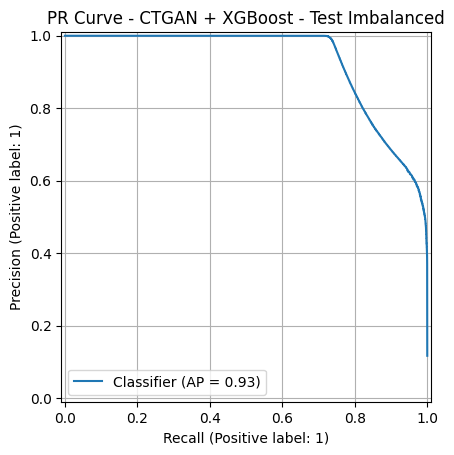

<Figure size 700x500 with 0 Axes>

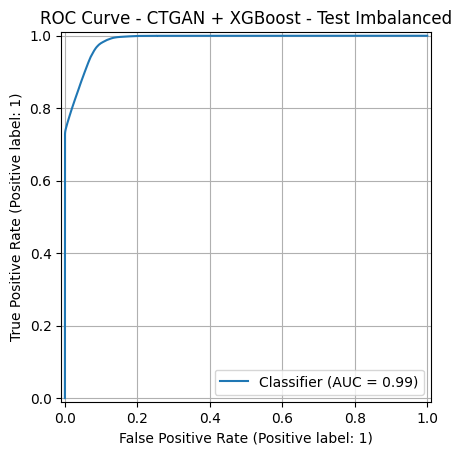

In [23]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

if RUN_FULL_CTGAN:
    plt.figure(figsize=(7,5))
    PrecisionRecallDisplay.from_predictions(y_test_work, score_test_imb)
    plt.title('PR Curve - CTGAN + XGBoost - Test Imbalanced')
    plt.grid(True)
    plt.savefig(OUT_DIR / 'pr_curve_ctgan_imbalanced.png', dpi=160, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(7,5))
    RocCurveDisplay.from_predictions(y_test_work, score_test_imb)
    plt.title('ROC Curve - CTGAN + XGBoost - Test Imbalanced')
    plt.grid(True)
    plt.savefig(OUT_DIR / 'roc_curve_ctgan_imbalanced.png', dpi=160, bbox_inches='tight')
    plt.show()
else:
    print('RUN_FULL_CTGAN=False')


## 17. Salvar relatório JSON

In [24]:
report = {
    'dataset': {
        'X_train_shape': tuple(X_train.shape),
        'X_test_shape': tuple(X_test.shape),
        'train_counts_original': train_counts,
        'test_counts_original': test_counts,
        'work_train_counts': class_counts(y_train_work),
        'model_train_counts': class_counts(y_train_model),
        'threshold_validation_counts': class_counts(y_val_threshold),
        'test_balanced_counts': class_counts(y_test_bal),
    },
    'params': {
        'xgboost': XGB_PARAMS,
        'ctgan': {
            'embedding_dim': CTGAN_EMBEDDING_DIM,
            'generator_dim': CTGAN_GENERATOR_DIM,
            'discriminator_dim': CTGAN_DISCRIMINATOR_DIM,
            'batch_size': CTGAN_BATCH_SIZE,
            'epochs': CTGAN_EPOCHS,
            'pac': CTGAN_PAC,
        },
        'quick_mode': QUICK_MODE,
        'run_full_ctgan': RUN_FULL_CTGAN,
        'use_validation_split': USE_VALIDATION_SPLIT,
        'validation_size': VALIDATION_SIZE,
        'apply_minmax_normalization': APPLY_MINMAX_NORMALIZATION,
        'synthetic_strategy': SYNTHETIC_STRATEGY,
        'clip_synthetic_to_attack_range': CLIP_SYNTHETIC_TO_ATTACK_RANGE,
        'target_recall': TARGET_RECALL,
        'fbeta_beta': FBETA_BETA,
    }
}

# Adiciona resultados ao JSON se os CSVs existirem.
results = {}
for name, csv_name in [
    ('baseline', 'baseline_results.csv'),
    ('ctgan_xgboost', 'ctgan_xgboost_results.csv'),
    ('comparison', 'all_results_comparison.csv'),
]:
    path = OUT_DIR / csv_name
    if path.exists():
        results[name] = pd.read_csv(path).to_dict(orient='records')
report['results'] = results

with open(OUT_DIR / 'experiment_report.json', 'w') as f:
    json.dump(report, f, indent=2, default=str)

print('Arquivos salvos em:', OUT_DIR)
!ls -lh /content/outputs_someip_xgboost


Arquivos salvos em: /content/outputs_someip_xgboost
total 258M
-rw-r--r-- 1 root root  725 Apr 29 22:11 all_results_comparison.csv
-rw-r--r-- 1 root root  394 Apr 29 21:31 baseline_results.csv
-rw-r--r-- 1 root root 979K Apr 29 21:57 ctgan_attack_only.joblib
-rw-r--r-- 1 root root  398 Apr 29 22:10 ctgan_xgboost_results.csv
-rw-r--r-- 1 root root  940 Apr 29 22:12 experiment_report.json
-rw-r--r-- 1 root root  45K Apr 29 22:12 pr_curve_ctgan_imbalanced.png
-rw-r--r-- 1 root root  47K Apr 29 22:12 roc_curve_ctgan_imbalanced.png
-rw-r--r-- 1 root root 250M Apr 29 22:04 synthetic_attacks.npy
-rw-r--r-- 1 root root 3.8M Apr 29 21:31 xgb_baseline_no_ctgan.joblib
-rw-r--r-- 1 root root 3.4M Apr 29 22:09 xgb_ctgan_augmented.joblib


## Observações práticas

- Se o Colab reiniciar por falta de RAM, primeiro rode com `QUICK_MODE=True`.
- Para reprodução final, use Colab Pro/Pro+ ou máquina local com bastante RAM.
- O threshold final agora é escolhido em uma validação estratificada do lado de treino (`X_val_threshold`), não no teste.
- A normalização Min-Max é aplicada com `fit` apenas no treino do modelo e `transform` em validação/teste.
- A estratégia `SYNTHETIC_STRATEGY='paper_table'` gera aproximadamente uma quantidade de ataques sintéticos igual ao número de normais, reproduzindo a Tabela 3 do artigo.
- Também são salvos resultados com threshold por F1, F-beta e recall alvo, permitindo avaliar o trade-off entre falso positivo e falso negativo.
